In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


In [2]:
!pip install pyforest

In [2]:
from pyforest import*
lazy_imports()


['from sklearn.preprocessing import MinMaxScaler',
 'from sklearn.manifold import TSNE',
 'from statsmodels.tsa.arima_model import ARIMA',
 'import numpy as np',
 'from fbprophet import Prophet',
 'from scipy import stats',
 'from sklearn.ensemble import GradientBoostingRegressor',
 'import pickle',
 'import plotly.graph_objs as go',
 'import skimage',
 'import fastai',
 'import lightgbm as lgb',
 'from xlrd import open_workbook',
 'import awswrangler as wr',
 'import plotly.express as px',
 'from sklearn.model_selection import KFold',
 'from openpyxl import load_workbook',
 'from sklearn.ensemble import GradientBoostingClassifier',
 'import nltk',
 'from sklearn.decomposition import PCA',
 'from pathlib import Path',
 'from sklearn.ensemble import RandomForestClassifier',
 'import pandas as pd',
 'from PIL import Image',
 'from sklearn.cluster import KMeans',
 'from sklearn.linear_model import RidgeCV',
 'import statsmodels.api as sm',
 'import glob',
 'from sklearn.feature_extraction

In [3]:
cancer_data = pd.read_csv('fetal_health.csv')

<IPython.core.display.Javascript object>

In [4]:
cancer_data

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.000,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.000,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.000,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.000,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.000,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.0,0.000,0.000,0.007,0.000,0.0,0.0,79.0,0.2,25.0,...,137.0,177.0,4.0,0.0,153.0,150.0,152.0,2.0,0.0,2.0
2122,140.0,0.001,0.000,0.007,0.000,0.0,0.0,78.0,0.4,22.0,...,103.0,169.0,6.0,0.0,152.0,148.0,151.0,3.0,1.0,2.0
2123,140.0,0.001,0.000,0.007,0.000,0.0,0.0,79.0,0.4,20.0,...,103.0,170.0,5.0,0.0,153.0,148.0,152.0,4.0,1.0,2.0
2124,140.0,0.001,0.000,0.006,0.000,0.0,0.0,78.0,0.4,27.0,...,103.0,169.0,6.0,0.0,152.0,147.0,151.0,4.0,1.0,2.0


In [5]:
cancer_data.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [6]:
#Data Pre-Processing 

In [8]:
cancer_data['accelerations'].value_counts()

0.000    894
0.003    161
0.002    160
0.001    143
0.004    117
0.006    112
0.005    110
0.008    103
0.007     91
0.009     60
0.010     50
0.011     36
0.012     24
0.013     22
0.014     20
0.015      9
0.016      7
0.017      4
0.018      2
0.019      1
Name: accelerations, dtype: int64

In [9]:
cancer_data.dtypes

baseline value                                            float64
accelerations                                             float64
fetal_movement                                            float64
uterine_contractions                                      float64
light_decelerations                                       float64
severe_decelerations                                      float64
prolongued_decelerations                                  float64
abnormal_short_term_variability                           float64
mean_value_of_short_term_variability                      float64
percentage_of_time_with_abnormal_long_term_variability    float64
mean_value_of_long_term_variability                       float64
histogram_width                                           float64
histogram_min                                             float64
histogram_max                                             float64
histogram_number_of_peaks                                 float64
histogram_

In [10]:
cancer_data.shape

(2126, 22)

In [12]:
cancer_data[cancer_data['mean_value_of_long_term_variability']=='?']

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health


In [21]:
cancer_data[cancer_data['mean_value_of_short_term_variability']=='?'].sum()

baseline value                                            0.0
accelerations                                             0.0
fetal_movement                                            0.0
uterine_contractions                                      0.0
light_decelerations                                       0.0
severe_decelerations                                      0.0
prolongued_decelerations                                  0.0
abnormal_short_term_variability                           0.0
mean_value_of_short_term_variability                      0.0
percentage_of_time_with_abnormal_long_term_variability    0.0
mean_value_of_long_term_variability                       0.0
histogram_width                                           0.0
histogram_min                                             0.0
histogram_max                                             0.0
histogram_number_of_peaks                                 0.0
histogram_number_of_zeroes                                0.0
histogra

In [22]:
#data cleaning 

In [23]:
df=cancer_data.replace('?', np.nan)

<IPython.core.display.Javascript object>

In [24]:
df.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [25]:
df['fetal_movement']

0       0.000
1       0.000
2       0.000
3       0.000
4       0.000
        ...  
2121    0.000
2122    0.000
2123    0.000
2124    0.000
2125    0.002
Name: fetal_movement, Length: 2126, dtype: float64

In [26]:
df.median()

baseline value                                            133.000
accelerations                                               0.002
fetal_movement                                              0.000
uterine_contractions                                        0.004
light_decelerations                                         0.000
severe_decelerations                                        0.000
prolongued_decelerations                                    0.000
abnormal_short_term_variability                            49.000
mean_value_of_short_term_variability                        1.200
percentage_of_time_with_abnormal_long_term_variability      0.000
mean_value_of_long_term_variability                         7.400
histogram_width                                            67.500
histogram_min                                              93.000
histogram_max                                             162.000
histogram_number_of_peaks                                   3.000
histogram_

In [27]:
df=df.fillna(df.median())

In [28]:
df['mean_value_of_short_term_variability']

0       0.5
1       2.1
2       2.1
3       2.4
4       2.4
       ... 
2121    0.2
2122    0.4
2123    0.4
2124    0.4
2125    0.4
Name: mean_value_of_short_term_variability, Length: 2126, dtype: float64

In [29]:
cancer_data.dtypes

baseline value                                            float64
accelerations                                             float64
fetal_movement                                            float64
uterine_contractions                                      float64
light_decelerations                                       float64
severe_decelerations                                      float64
prolongued_decelerations                                  float64
abnormal_short_term_variability                           float64
mean_value_of_short_term_variability                      float64
percentage_of_time_with_abnormal_long_term_variability    float64
mean_value_of_long_term_variability                       float64
histogram_width                                           float64
histogram_min                                             float64
histogram_max                                             float64
histogram_number_of_peaks                                 float64
histogram_

In [30]:
df.dtypes

baseline value                                            float64
accelerations                                             float64
fetal_movement                                            float64
uterine_contractions                                      float64
light_decelerations                                       float64
severe_decelerations                                      float64
prolongued_decelerations                                  float64
abnormal_short_term_variability                           float64
mean_value_of_short_term_variability                      float64
percentage_of_time_with_abnormal_long_term_variability    float64
mean_value_of_long_term_variability                       float64
histogram_width                                           float64
histogram_min                                             float64
histogram_max                                             float64
histogram_number_of_peaks                                 float64
histogram_

In [31]:
##Explortory data analysis 

In [32]:
df.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [33]:
df.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [34]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
baseline value,2126.0,133.303857,9.840844,106.0,126.000,133.000,140.000,160.000
accelerations,2126.0,0.003178,0.003866,0.0,0.000,0.002,0.006,0.019
fetal_movement,2126.0,0.009481,0.046666,0.0,0.000,0.000,0.003,0.481
uterine_contractions,2126.0,0.004366,0.002946,0.0,0.002,0.004,0.007,0.015
light_decelerations,2126.0,0.001889,0.002960,0.0,0.000,0.000,0.003,0.015
severe_decelerations,2126.0,0.000003,0.000057,0.0,0.000,0.000,0.000,0.001
prolongued_decelerations,2126.0,0.000159,0.000590,0.0,0.000,0.000,0.000,0.005
abnormal_short_term_variability,2126.0,46.990122,17.192814,12.0,32.000,49.000,61.000,87.000
mean_value_of_short_term_variability,2126.0,1.332785,0.883241,0.2,0.700,1.200,1.700,7.000
percentage_of_time_with_abnormal_long_term_variability,2126.0,9.846660,18.396880,0.0,0.000,0.000,11.000,91.000


In [35]:
###Bivariate data analysis 

<IPython.core.display.Javascript object>

C:\Users\hp\anaconda3\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='mean_value_of_short_term_variability', ylabel='Density'>

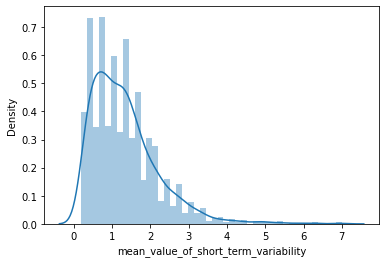

In [37]:
sns.distplot(df['mean_value_of_short_term_variability'])

<IPython.core.display.Javascript object>

C:\Users\hp\anaconda3\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='mean_value_of_short_term_variability', ylabel='Density'>

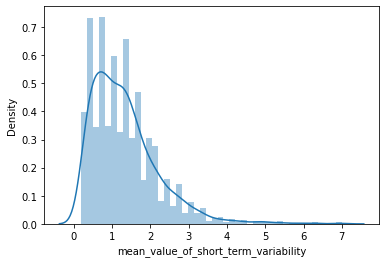

In [38]:
sns.distplot(df['mean_value_of_short_term_variability'])

In [39]:
###Multivariate data analysis

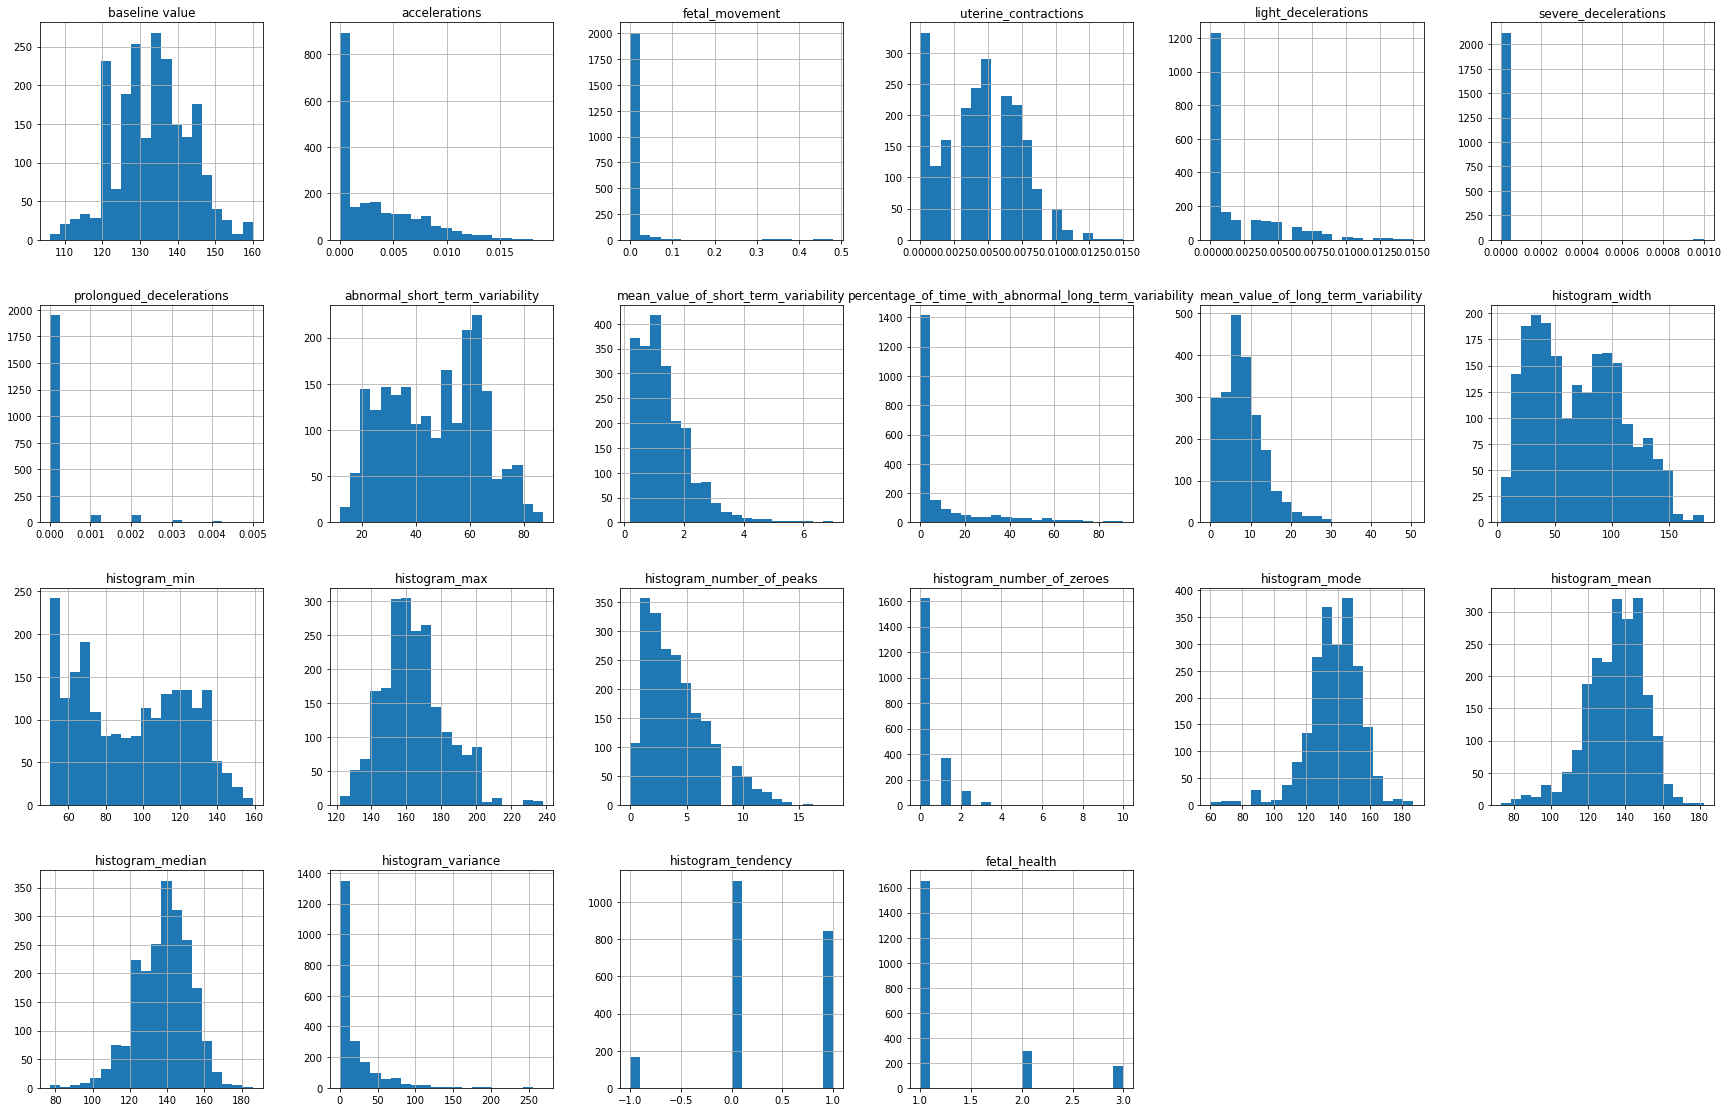

In [40]:
df.hist(bins=20,figsize=(30,30), layout=(6,6));

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<AxesSubplot:>

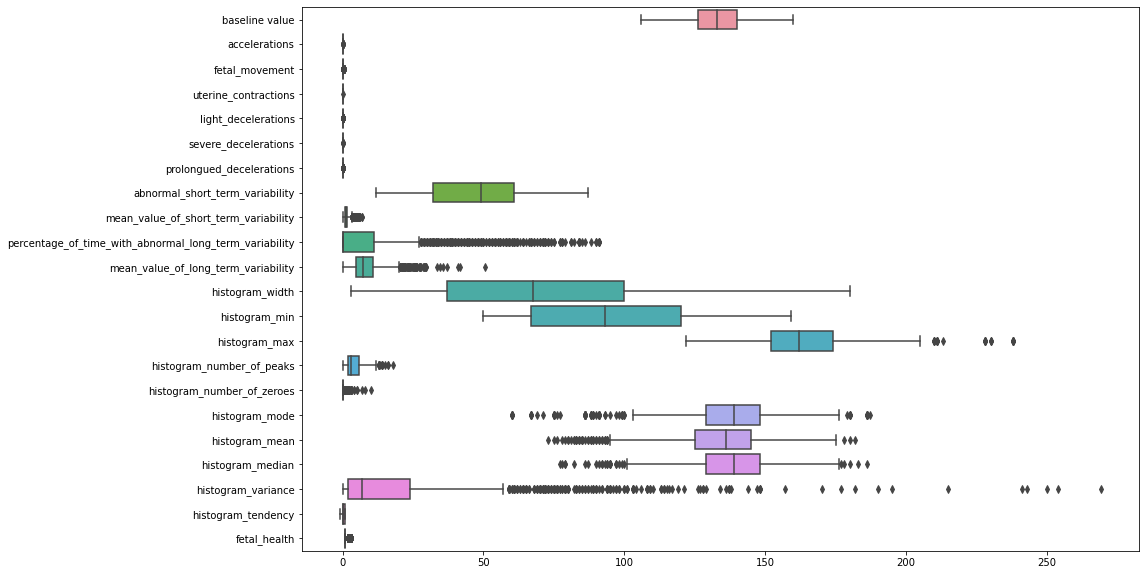

In [41]:
plt.figure(figsize=(15,10))
sns.boxplot(data=df, orient='h')

In [42]:
df.corr()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
baseline value,1.000000,-0.080560,-0.033436,-0.146373,-0.159032,-0.053518,-0.104597,0.305570,-0.279607,0.285630,...,0.361619,0.275110,-0.113933,-0.004745,0.708993,0.723121,0.789246,-0.133938,0.293503,0.148151
accelerations,-0.080560,1.000000,0.048235,0.089674,-0.108615,-0.043018,-0.127749,-0.279577,0.207170,-0.373943,...,-0.154286,0.394147,0.190452,-0.006147,0.243610,0.270334,0.272849,0.125704,0.028420,-0.364066
fetal_movement,-0.033436,0.048235,1.000000,-0.068779,0.049228,-0.010976,0.265922,-0.103715,0.121314,-0.074096,...,-0.153917,0.099853,0.164654,-0.017749,-0.061192,-0.089671,-0.072329,0.179340,-0.001541,0.088010
uterine_contractions,-0.146373,0.089674,-0.068779,1.000000,0.285079,0.006788,0.077036,-0.232811,0.289679,-0.306608,...,-0.113323,0.122766,0.082693,0.057894,-0.104854,-0.187505,-0.140287,0.238582,-0.072314,-0.204894
light_decelerations,-0.159032,-0.108615,0.049228,0.285079,1.000000,0.107573,0.225611,-0.119152,0.562170,-0.271282,...,-0.553534,0.218043,0.397620,0.235296,-0.347233,-0.527354,-0.388586,0.564289,0.000072,0.058870
severe_decelerations,-0.053518,-0.043018,-0.010976,0.006788,0.107573,1.000000,0.012395,0.033949,0.034130,-0.030770,...,-0.071974,-0.021135,0.007024,0.043441,-0.215161,-0.158673,-0.160451,0.136421,-0.070483,0.131934
prolongued_decelerations,-0.104597,-0.127749,0.265922,0.077036,0.225611,0.012395,1.000000,0.046226,0.267011,-0.137333,...,-0.276764,0.120221,0.222860,0.056423,-0.436416,-0.488663,-0.444778,0.503301,-0.215405,0.484859
abnormal_short_term_variability,0.305570,-0.279577,-0.103715,-0.232811,-0.119152,0.033949,0.046226,1.000000,-0.430705,0.459413,...,0.275378,-0.111806,-0.167561,-0.149296,0.058363,0.074554,0.119960,-0.146434,-0.005748,0.471191
mean_value_of_short_term_variability,-0.279607,0.207170,0.121314,0.289679,0.562170,0.034130,0.267011,-0.430705,1.000000,-0.470259,...,-0.622569,0.409072,0.501430,0.266183,-0.307586,-0.445401,-0.336109,0.555852,-0.066140,-0.103382
percentage_of_time_with_abnormal_long_term_variability,0.285630,-0.373943,-0.074096,-0.306608,-0.271282,-0.030770,-0.137333,0.459413,-0.470259,1.000000,...,0.422834,-0.283183,-0.279301,-0.121784,0.165211,0.222321,0.186480,-0.281536,0.042481,0.426146


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

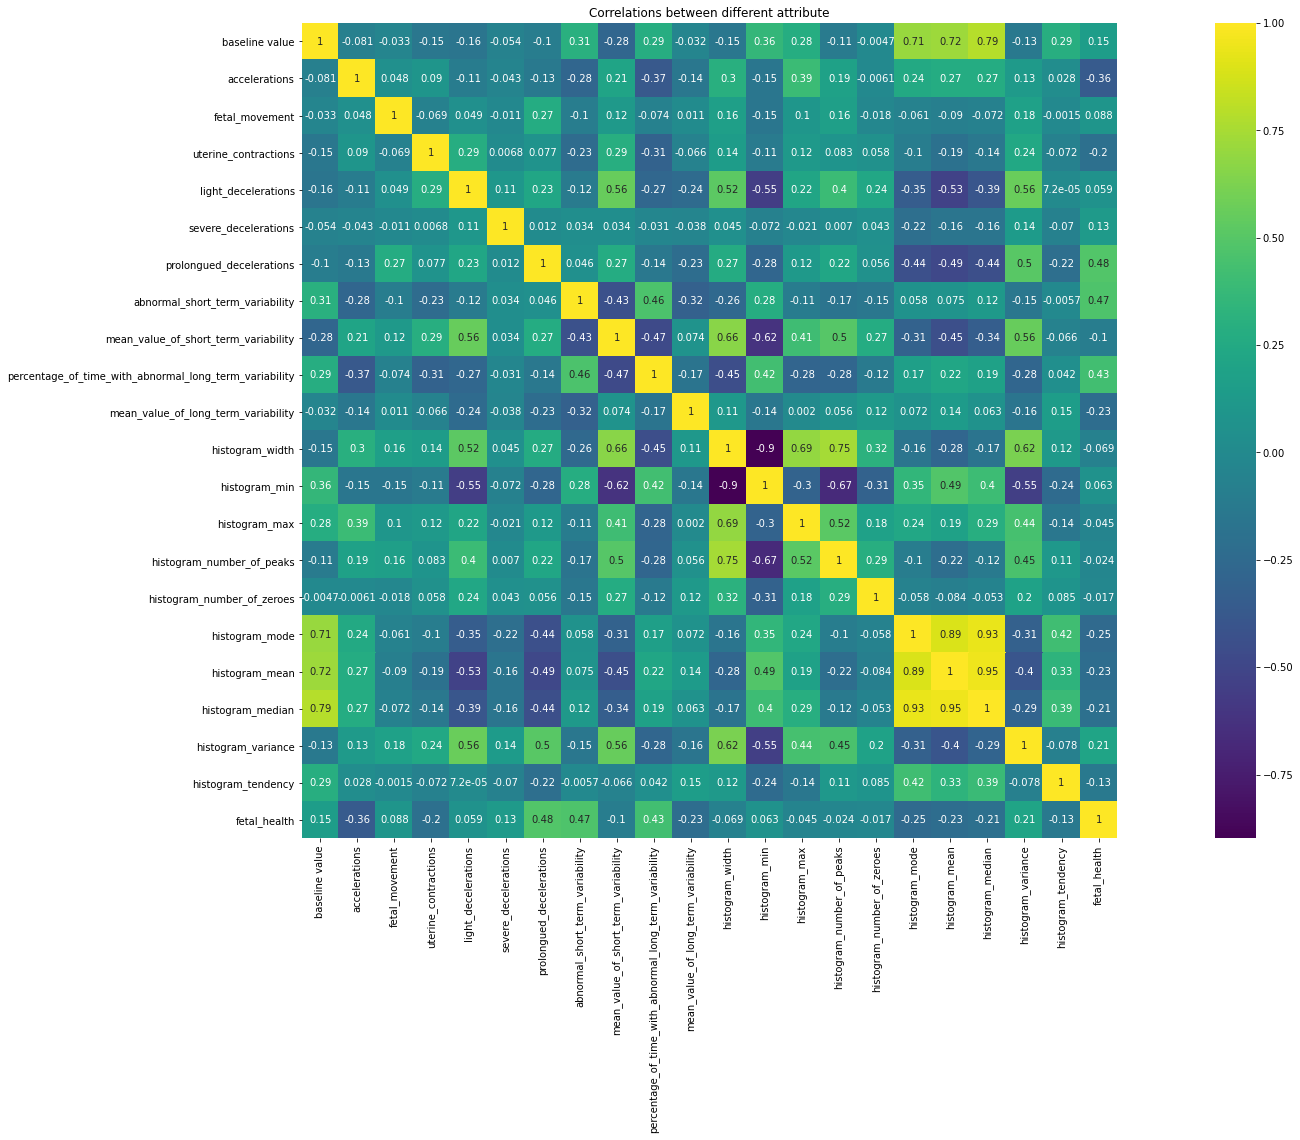

In [43]:
plt.figure(figsize=(35,15))
sns.heatmap(df.corr(),vmax=1, square=True, annot=True,cmap='viridis')
plt.title('Correlations between different attribute')
plt.show()

<IPython.core.display.Javascript object>

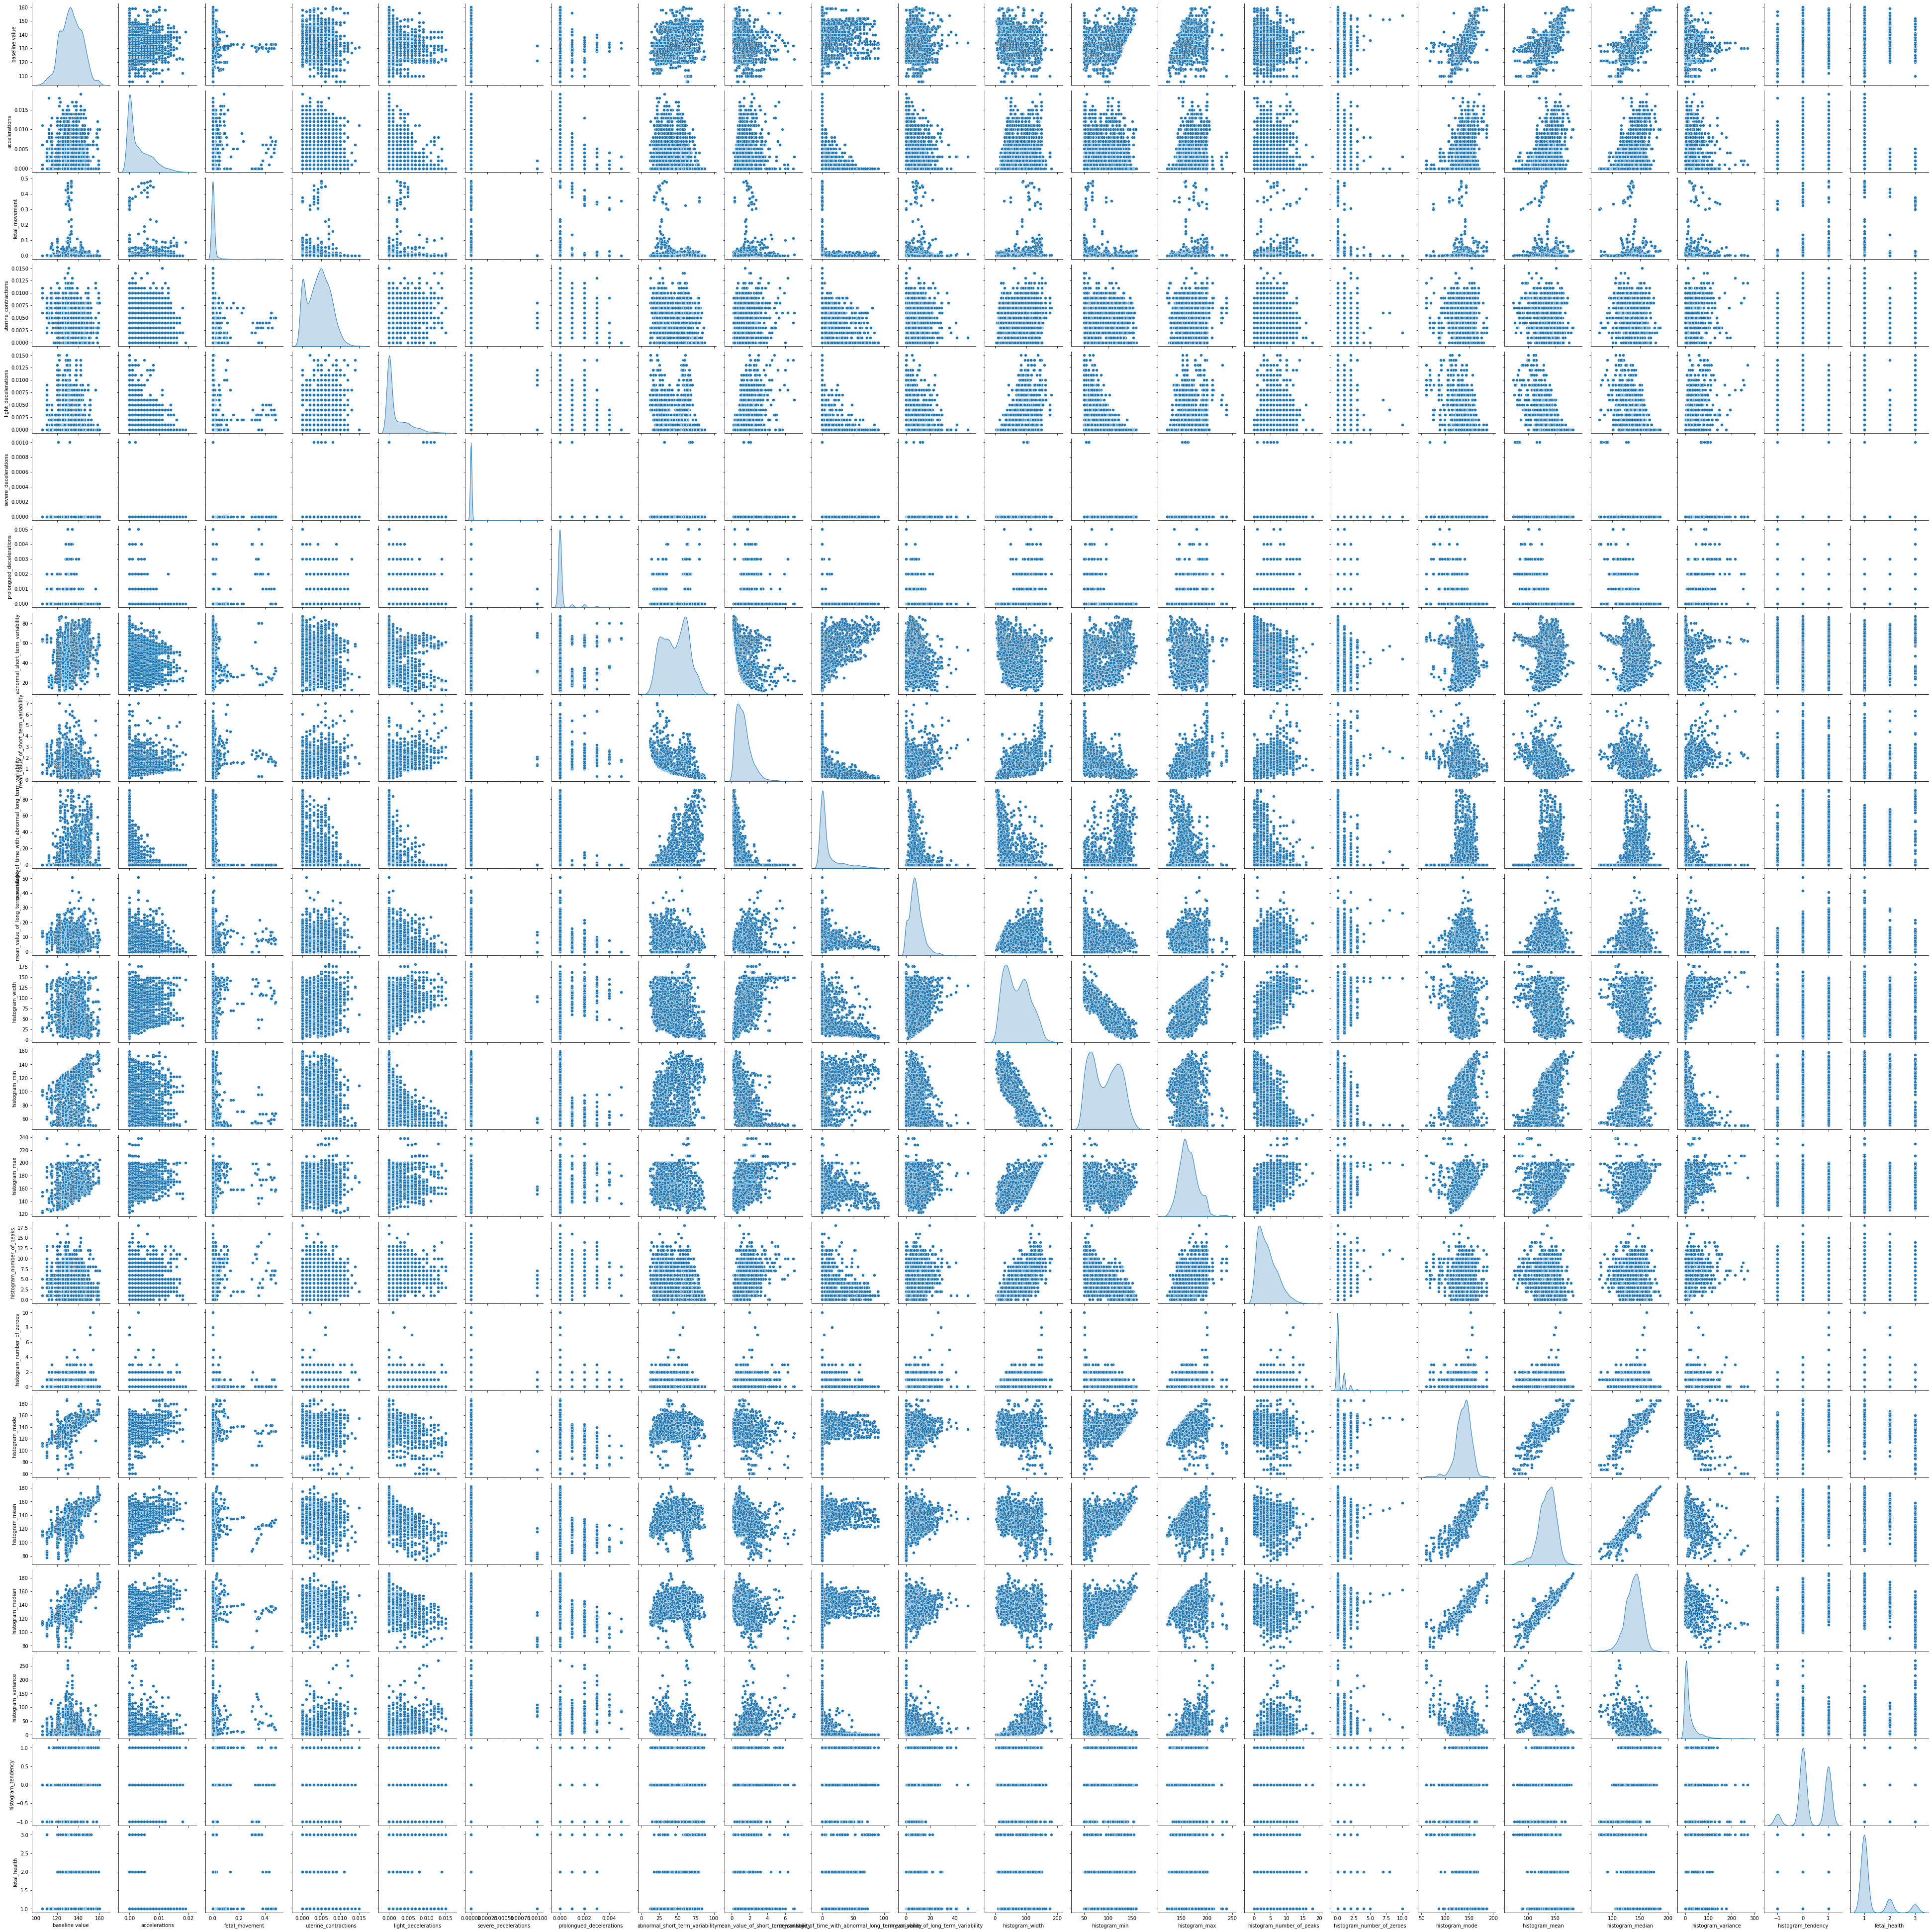

In [44]:
sns.pairplot(df,diag_kind='kde')

In [45]:
#Building Model

In [26]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,0,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [53]:
X = df.drop('histogram_number_of_peaks', axis=1)
y = df['histogram_number_of_peaks']

In [54]:
from sklearn.model_selection import train_test_split


In [55]:
#Split 70:30

X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.30,random_state=1)

In [56]:
#KNeighbours Classifier 

In [57]:
from sklearn.neighbors import KNeighborsClassifier

In [58]:
KNN = KNeighborsClassifier(n_neighbors=5, weights='distance')

In [59]:
KNN.fit(X_train, y_train)

KNeighborsClassifier(weights='distance')

In [60]:
predicted_1=KNN.predict(X_test)
predicted_1

array([ 5.,  5.,  2.,  4.,  1.,  2.,  4., 10.,  6.,  1.,  4.,  8.,  0.,
        1.,  0.,  3.,  3.,  9.,  1.,  7.,  1.,  5.,  2.,  0.,  0.,  3.,
        2., 10.,  4., 12.,  1.,  5.,  1.,  3., 10.,  8.,  8.,  1.,  7.,
        2.,  1., 11.,  3.,  3.,  6.,  6.,  5.,  2.,  1.,  2.,  7.,  4.,
        2.,  1.,  2.,  3.,  1.,  2.,  0.,  1.,  6.,  5.,  3.,  6.,  9.,
        2.,  3.,  1.,  1., 11.,  1.,  5.,  8.,  5.,  4.,  5.,  8.,  2.,
        7.,  4.,  5.,  1.,  5.,  8.,  1.,  1.,  3.,  2.,  5.,  7.,  3.,
        8.,  1.,  1.,  5.,  1.,  1.,  8.,  3., 13.,  2.,  2.,  3.,  8.,
        4.,  1.,  1.,  2.,  8.,  2.,  2.,  1.,  5.,  1.,  1.,  1.,  8.,
        1.,  6.,  1.,  2.,  0.,  1.,  3.,  1.,  1.,  2.,  1.,  2.,  1.,
        3.,  2.,  5.,  3.,  2.,  2.,  2.,  2.,  6.,  5.,  5.,  6.,  8.,
        4.,  3.,  1.,  9.,  1.,  2.,  1.,  2.,  4.,  1.,  2.,  1.,  4.,
        6.,  7.,  2.,  1.,  0.,  2.,  5.,  1.,  1.,  2.,  5.,  2.,  1.,
        7.,  0.,  1.,  4.,  1., 11., 10.,  2.,  5., 11.,  7.,  5

In [61]:
X_test

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_width,histogram_min,histogram_max,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
669,141.0,0.001,0.000,0.001,0.003,0.0,0.000,54.0,0.9,7.0,...,124.0,60.0,184.0,2.0,150.0,139.0,147.0,49.0,1.0,1.0
1205,143.0,0.000,0.000,0.006,0.000,0.0,0.000,63.0,0.5,35.0,...,33.0,128.0,161.0,0.0,147.0,146.0,148.0,0.0,0.0,2.0
870,136.0,0.008,0.000,0.007,0.000,0.0,0.000,42.0,0.7,20.0,...,38.0,120.0,158.0,1.0,141.0,143.0,144.0,3.0,0.0,1.0
547,138.0,0.000,0.029,0.005,0.002,0.0,0.000,59.0,0.5,26.0,...,54.0,100.0,154.0,0.0,147.0,145.0,148.0,3.0,1.0,2.0
1806,143.0,0.000,0.000,0.001,0.000,0.0,0.000,68.0,0.3,6.0,...,27.0,132.0,159.0,0.0,144.0,144.0,146.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1726,134.0,0.003,0.001,0.007,0.005,0.0,0.001,59.0,1.4,0.0,...,72.0,83.0,155.0,1.0,137.0,127.0,136.0,35.0,1.0,1.0
208,124.0,0.005,0.015,0.002,0.000,0.0,0.000,46.0,0.8,0.0,...,52.0,90.0,142.0,0.0,129.0,130.0,131.0,2.0,1.0,1.0
288,144.0,0.000,0.009,0.000,0.000,0.0,0.000,58.0,0.6,1.0,...,39.0,125.0,164.0,0.0,143.0,142.0,144.0,1.0,0.0,1.0
1116,122.0,0.000,0.000,0.001,0.001,0.0,0.000,25.0,1.4,3.0,...,31.0,105.0,136.0,0.0,126.0,122.0,124.0,5.0,0.0,1.0


In [62]:
from scipy.stats import zscore

print('KNeighborsClassifier Algorithm is predicted at', KNN.score(X_test,y_test)*100)

KNeighborsClassifier Algorithm is predicted at 29.153605015673982


In [63]:
#Support Vector Machine Classifier

In [64]:
from sklearn.svm import SVC
svc=SVC(gamma=0.025,C=3)
svc.fit(X_train,y_train)

SVC(C=3, gamma=0.025)

In [65]:
predicted_2=svc.predict(X_test)
predicted_2

array([ 2.,  1.,  2.,  2.,  1.,  2.,  4.,  2.,  2.,  1.,  2.,  2.,  1.,
        1.,  3.,  2.,  2.,  2.,  2.,  2.,  1.,  5.,  2.,  0.,  2.,  2.,
        1.,  2.,  2., 12.,  1.,  3.,  2.,  3.,  2.,  8.,  8.,  1.,  2.,
        2.,  1., 11.,  3.,  3.,  6.,  2.,  2.,  2.,  1.,  2.,  7.,  2.,
        2.,  1.,  2.,  2.,  1.,  2.,  1.,  2.,  6.,  5.,  2.,  6.,  2.,
        2.,  2.,  1.,  1.,  2.,  2.,  2.,  6.,  5.,  2.,  2.,  2.,  2.,
        2.,  4.,  5.,  2.,  5.,  2.,  2.,  1.,  2.,  2.,  2.,  7.,  2.,
        2.,  2.,  1.,  5.,  1.,  1.,  2.,  2.,  2.,  2.,  2.,  1.,  8.,
        4.,  2.,  1.,  2.,  2.,  2.,  2.,  3.,  2.,  1.,  1.,  1.,  8.,
        1.,  2.,  2.,  2.,  0.,  2.,  2.,  1.,  1.,  2.,  2.,  2.,  2.,
        2.,  1.,  5.,  2.,  2.,  2.,  2.,  2.,  6.,  2.,  5.,  4.,  2.,
        2.,  3.,  1.,  9.,  1.,  2.,  1.,  2.,  2.,  1.,  2.,  1.,  2.,
        6.,  2.,  2.,  2.,  2.,  2.,  5.,  2.,  1.,  2.,  5.,  2.,  1.,
        2.,  0.,  2.,  2.,  2., 11.,  2.,  2.,  5.,  2.,  7.,  2

In [66]:
print('SVM Algorithm is predicted at', svc.score(X_test,y_test)*100)

SVM Algorithm is predicted at 27.11598746081505


In [67]:
knnPredictions=pd.DataFrame(predicted_1)
svcpredictions=pd.DataFrame(predicted_2)

df1=pd.concat([knnPredictions,svcpredictions],axis=1)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [68]:
df1

,0,0
0,5.0,2.0
1,5.0,1.0
2,2.0,2.0
3,4.0,2.0
4,1.0,1.0
...,...,...
633,5.0,2.0
634,4.0,2.0
635,3.0,3.0
636,1.0,1.0


In [69]:
df1.columns=[['knnPredictions', 'svcpredictions']]

In [70]:
df1

,knnPredictions,svcpredictions
0,5.0,2.0
1,5.0,1.0
2,2.0,2.0
3,4.0,2.0
4,1.0,1.0
...,...,...
633,5.0,2.0
634,4.0,2.0
635,3.0,3.0
636,1.0,1.0


In [71]:
from sklearn.metrics import classification_report

In [72]:
print('KNN Classification report')
print('..........')
print(classification_report(y_test,predicted_1))

KNN Classification report
..........
              precision    recall  f1-score   support

         0.0       0.40      0.36      0.38        33
         1.0       0.51      0.51      0.51       129
         2.0       0.35      0.44      0.39        95
         3.0       0.21      0.20      0.21        70
         4.0       0.18      0.17      0.17        66
         5.0       0.17      0.17      0.17        64
         6.0       0.14      0.14      0.14        42
         7.0       0.23      0.22      0.23        41
         8.0       0.22      0.22      0.22        36
         9.0       0.12      0.11      0.11        19
        10.0       0.13      0.10      0.11        20
        11.0       0.14      0.10      0.12        10
        12.0       0.20      0.12      0.15         8
        13.0       0.00      0.00      0.00         2
        14.0       0.50      0.50      0.50         2
        15.0       0.00      0.00      0.00         1

    accuracy                           0.29

C:\Users\hp\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\hp\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\hp\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [73]:
print('SVC Classification report')
print('..........')
print(classification_report(y_test,predicted_2))

SVC Classification report
..........
              precision    recall  f1-score   support

         0.0       0.38      0.18      0.24        33
         1.0       0.59      0.46      0.52       129
         2.0       0.17      0.66      0.28        95
         3.0       0.32      0.17      0.22        70
         4.0       0.32      0.12      0.18        66
         5.0       0.19      0.09      0.13        64
         6.0       0.24      0.10      0.14        42
         7.0       0.28      0.12      0.17        41
         8.0       0.33      0.11      0.17        36
         9.0       0.20      0.11      0.14        19
        10.0       0.50      0.05      0.09        20
        11.0       0.50      0.10      0.17        10
        12.0       0.50      0.12      0.20         8
        13.0       0.00      0.00      0.00         2
        14.0       1.00      0.50      0.67         2
        15.0       0.00      0.00      0.00         1

    accuracy                           0.27

C:\Users\hp\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\hp\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\hp\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
